c:\Users\aaryan\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


📂 Loading Peak-Centered data...
✅ Loaded 9493 training samples.
✅ Training set: 9493 samples
✅ Test set: 2374 samples
   Class distribution (train): [4688 4805]
   Class distribution (test): [1124 1250]


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 32)             │         3,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Starting Final Training...
Epoch 1/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9301 - loss: 0.2921 - val_accuracy: 0.9768 - val_loss: 0.1067
Epoch 2/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9794 - loss: 0.0839 - val_accuracy: 0.9824 - val_loss: 0.0680
Epoch 3/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9838 - loss: 0.0597 - val_accuracy: 0.9838 - val_loss: 0.0577
Epoch 4/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9849 - loss: 0.0508 - val_accuracy: 0.9846 - val_loss: 0.0533
Epoch 5/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9855 - loss: 0.0454 - val_accuracy: 0.9860 - val_loss: 0.0488
Epoch 6/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9867 - loss: 0.0418 - val_accuracy: 0.9867 - val_loss: 0.0475
Epoch 7/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9870 - loss: 0.0390 - val_accuracy: 0.9874 - val_loss: 0.0457
Epoch 8/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9872 - l


📈 Overall Metrics:
   Test Accuracy:  98.82%
   Test Loss:      0.0295

🎯 Classification Metrics:
   Precision:      100.00% (of predicted positives, how many were correct)
   Recall:         97.76% (of actual positives, how many were detected)
   F1-Score:       98.87% (harmonic mean of precision and recall)

📋 Detailed Classification Report:
              precision    recall  f1-score   support

 No Peak (0)     0.9757    1.0000    0.9877      1124
  R-Peak (1)     1.0000    0.9776    0.9887      1250

    accuracy                         0.9882      2374
   macro avg     0.9878    0.9888    0.9882      2374
weighted avg     0.9885    0.9882    0.9882      2374


📊 Confusion Matrix:
   True Negatives (TN):  1,124
   False Positives (FP): 0
   False Negatives (FN): 28
   True Positives (TP):  1,222

🔍 Additional Metrics:
   Specificity:    100.00% (True Negative Rate)
   Sensitivity:    97.76% (True Positive Rate = Recall)

📉 ROC Analysis:
   AUC-ROC:        0.9991 (Area Under ROC Cu

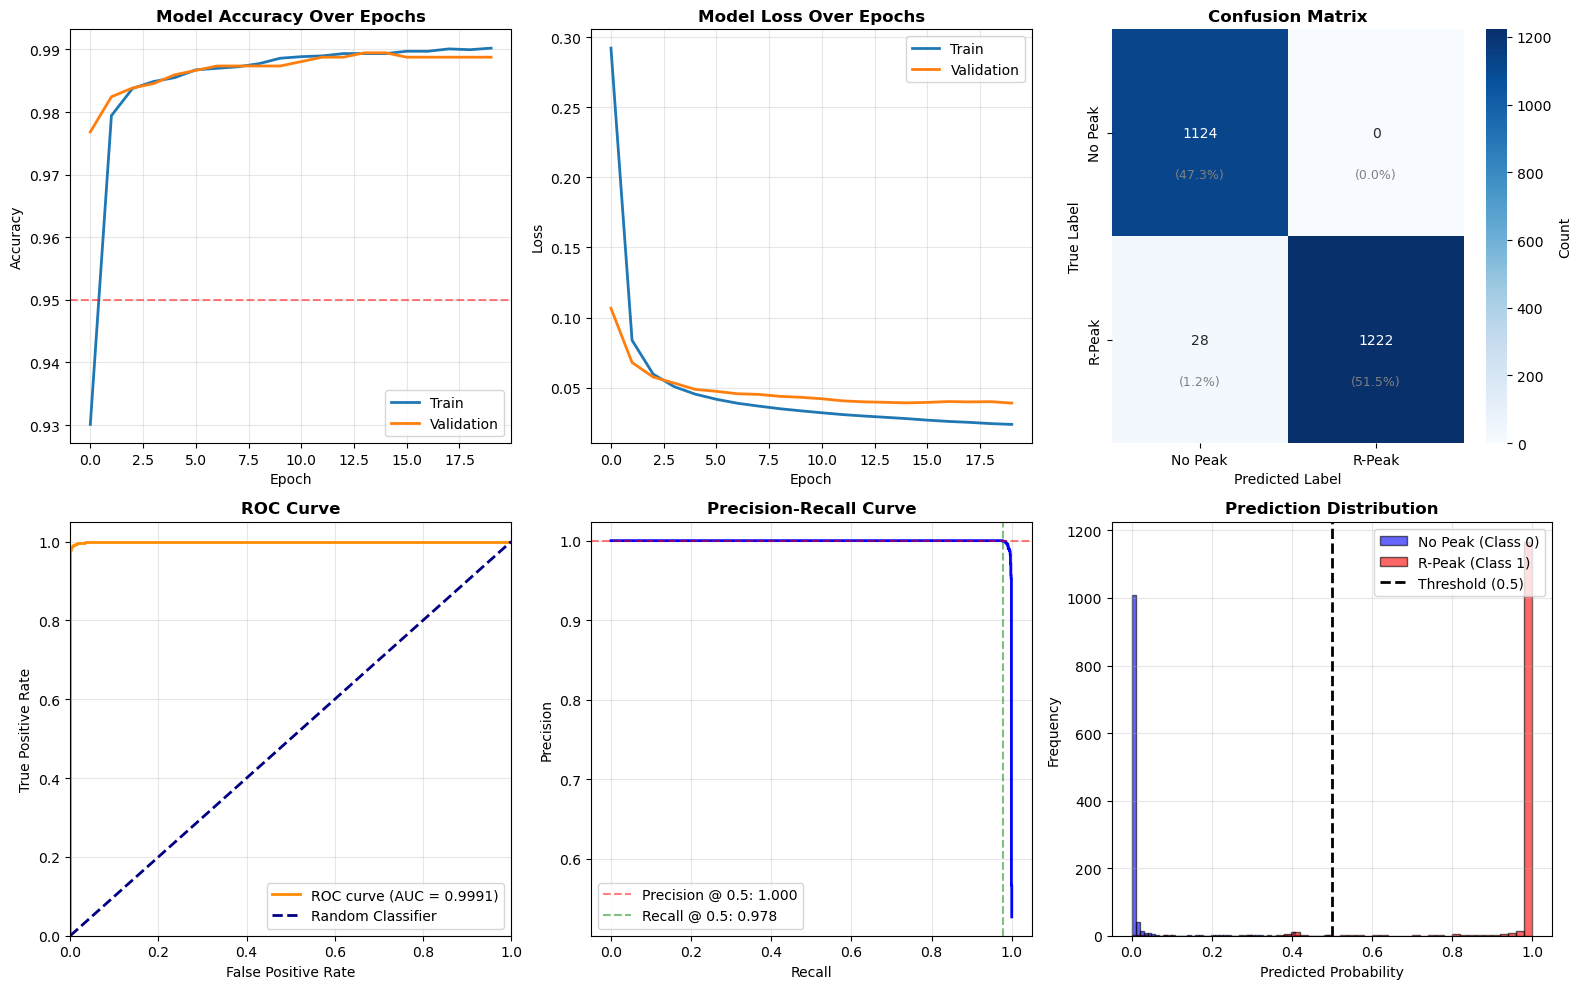

✅ Saved detailed metrics: ./model_outputs\model_metrics.txt

PHASE 2 SUMMARY
✅ Model trained successfully
✅ Test Accuracy: 98.82%
✅ F1-Score: 98.87%
✅ AUC-ROC: 0.9991
✅ All weights and test data saved

🎯 Model is ready for FPGA deployment!
📂 Next step: Run phase3_quantization.py



In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    roc_curve, auc, precision_recall_curve,
    f1_score, precision_score, recall_score
)
import seaborn as sns
import os

# --- 1. CONFIGURATION (Hardware Optimized) ---
INPUT_SIZE = 100    # 100-point ECG window
HIDDEN_NEURONS = 32 # Balanced for FPGA resource constraints
EPOCHS = 20         # With centered data, it will learn very fast
BATCH_SIZE = 32

# --- 2. LOAD CENTERED DATA ---
data_dir = './processed_data'

print("📂 Loading Peak-Centered data...")
try:
    X_train = np.load(os.path.join(data_dir, 'X_train.npy'))
    y_train = np.load(os.path.join(data_dir, 'y_train.npy'))
    X_test = np.load(os.path.join(data_dir, 'X_test.npy'))
    y_test = np.load(os.path.join(data_dir, 'y_test.npy'))
    print(f"✅ Loaded {len(X_train)} training samples.")
    print(f"✅ Training set: {len(X_train)} samples")
    print(f"✅ Test set: {len(X_test)} samples")
    print(f"   Class distribution (train): {np.bincount(y_train.astype(int))}")
    print(f"   Class distribution (test): {np.bincount(y_test.astype(int))}")
except FileNotFoundError:
    print("❌ ERROR: Could not find processed_data. Ensure the Recovery Script ran successfully.")
    exit()

# --- 3. BUILD MLP ARCHITECTURE ---
# Design: Input (100) -> Dense (32, ReLU) -> Dense (1, Sigmoid)
model = Sequential([
    Input(shape=(INPUT_SIZE,)),
    # ReLU: Simple hardware implementation (max(0, x))
    Dense(HIDDEN_NEURONS, activation='relu', name='hidden_layer'),
    # Sigmoid: Maps output to 0.0 - 1.0 probability
    Dense(1, activation='sigmoid', name='output_layer')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# --- 4. TRAINING ---
print("\n🚀 Starting Final Training...")
history = model.fit(
    X_train, y_train,
    validation_split=0.15, # Use 15% of training for internal validation
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

# --- 5. PREDICTIONS ---
print("\n📊 Generating predictions on test set...")
y_pred_probs = model.predict(X_test, verbose=0).flatten()
y_pred = (y_pred_probs >= 0.5).astype(int)

# --- 6. COMPREHENSIVE EVALUATION ---
print("\n" + "="*70)
print("COMPREHENSIVE MODEL EVALUATION")
print("="*70)

# Basic Metrics
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\n📈 Overall Metrics:")
print(f"   Test Accuracy:  {accuracy*100:.2f}%")
print(f"   Test Loss:      {loss:.4f}")

# Precision, Recall, F1-Score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\n🎯 Classification Metrics:")
print(f"   Precision:      {precision*100:.2f}% (of predicted positives, how many were correct)")
print(f"   Recall:         {recall*100:.2f}% (of actual positives, how many were detected)")
print(f"   F1-Score:       {f1*100:.2f}% (harmonic mean of precision and recall)")

# Detailed Classification Report
print(f"\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred, 
                          target_names=['No Peak (0)', 'R-Peak (1)'],
                          digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\n📊 Confusion Matrix:")
print(f"   True Negatives (TN):  {cm[0,0]:,}")
print(f"   False Positives (FP): {cm[0,1]:,}")
print(f"   False Negatives (FN): {cm[1,0]:,}")
print(f"   True Positives (TP):  {cm[1,1]:,}")

# Calculate specificity and sensitivity
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

print(f"\n🔍 Additional Metrics:")
print(f"   Specificity:    {specificity*100:.2f}% (True Negative Rate)")
print(f"   Sensitivity:    {sensitivity*100:.2f}% (True Positive Rate = Recall)")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

print(f"\n📉 ROC Analysis:")
print(f"   AUC-ROC:        {roc_auc:.4f} (Area Under ROC Curve)")

# --- 7. WEIGHT EXTRACTION (BRIDGE TO VERILOG) ---
# We extract the math so we can hard-code it into the FPGA
output_dir = './model_outputs'
os.makedirs(output_dir, exist_ok=True)

# Extract Hidden Layer Weights (100 inputs x 32 neurons) and Biases (32)
w_hidden, b_hidden = model.get_layer('hidden_layer').get_weights()

# Extract Output Layer Weights (32 inputs x 1 neuron) and Bias (1)
w_output, b_output = model.get_layer('output_layer').get_weights()

# Save as .npy for Phase 3 (Quantization)
np.save(os.path.join(output_dir, 'weights_hidden.npy'), w_hidden)
np.save(os.path.join(output_dir, 'bias_hidden.npy'), b_hidden)
np.save(os.path.join(output_dir, 'weights_output.npy'), w_output)
np.save(os.path.join(output_dir, 'bias_output.npy'), b_output)

# IMPORTANT: Also save test data for Phase 3 quantization verification
np.save(os.path.join(output_dir, 'X_test.npy'), X_test)
np.save(os.path.join(output_dir, 'y_test.npy'), y_test)

# Save predictions for analysis
np.save(os.path.join(output_dir, 'y_pred_probs.npy'), y_pred_probs)
np.save(os.path.join(output_dir, 'y_pred.npy'), y_pred)

# Save the full model for reference
model.save(os.path.join(output_dir, 'heartbeat_model_final.h5'))

print(f"\n✅ SUCCESS: Phase 2 Complete.")
print(f"💾 Weights saved to {output_dir}/")
print(f"   - weights_hidden.npy")
print(f"   - bias_hidden.npy")
print(f"   - weights_output.npy")
print(f"   - bias_output.npy")
print(f"   - X_test.npy (for Phase 3 verification)")
print(f"   - y_test.npy (for Phase 3 verification)")
print(f"\n🚀 Ready for Phase 3 (Quantization)!")

# --- 8. COMPREHENSIVE VISUALIZATION ---
print("\n📊 Generating visualizations...")

# Create a figure with multiple subplots
fig = plt.figure(figsize=(16, 10))

# 1. Training History - Accuracy
ax1 = plt.subplot(2, 3, 1)
ax1.plot(history.history['accuracy'], label='Train', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
ax1.set_title('Model Accuracy Over Epochs', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0.95, color='r', linestyle='--', alpha=0.5, label='95% Target')

# 2. Training History - Loss
ax2 = plt.subplot(2, 3, 2)
ax2.plot(history.history['loss'], label='Train', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation', linewidth=2)
ax2.set_title('Model Loss Over Epochs', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Confusion Matrix
ax3 = plt.subplot(2, 3, 3)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Peak', 'R-Peak'],
            yticklabels=['No Peak', 'R-Peak'],
            cbar_kws={'label': 'Count'},
            ax=ax3)
ax3.set_title('Confusion Matrix', fontsize=12, fontweight='bold')
ax3.set_ylabel('True Label')
ax3.set_xlabel('Predicted Label')

# Add percentage annotations
for i in range(2):
    for j in range(2):
        percentage = cm[i, j] / cm.sum() * 100
        ax3.text(j + 0.5, i + 0.7, f'({percentage:.1f}%)', 
                ha='center', va='center', fontsize=9, color='gray')

# 4. ROC Curve
ax4 = plt.subplot(2, 3, 4)
ax4.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.4f})')
ax4.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax4.set_xlim([0.0, 1.0])
ax4.set_ylim([0.0, 1.05])
ax4.set_xlabel('False Positive Rate')
ax4.set_ylabel('True Positive Rate')
ax4.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax4.legend(loc="lower right")
ax4.grid(True, alpha=0.3)

# 5. Precision-Recall Curve
ax5 = plt.subplot(2, 3, 5)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_probs)
ax5.plot(recall_curve, precision_curve, color='blue', lw=2)
ax5.set_xlabel('Recall')
ax5.set_ylabel('Precision')
ax5.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3)
ax5.axhline(y=precision, color='r', linestyle='--', alpha=0.5, 
            label=f'Precision @ 0.5: {precision:.3f}')
ax5.axvline(x=recall, color='g', linestyle='--', alpha=0.5, 
            label=f'Recall @ 0.5: {recall:.3f}')
ax5.legend()

# 6. Prediction Distribution
ax6 = plt.subplot(2, 3, 6)
ax6.hist(y_pred_probs[y_test == 0], bins=50, alpha=0.6, label='No Peak (Class 0)', 
         color='blue', edgecolor='black')
ax6.hist(y_pred_probs[y_test == 1], bins=50, alpha=0.6, label='R-Peak (Class 1)', 
         color='red', edgecolor='black')
ax6.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold (0.5)')
ax6.set_xlabel('Predicted Probability')
ax6.set_ylabel('Frequency')
ax6.set_title('Prediction Distribution', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'comprehensive_evaluation.png'), dpi=300, bbox_inches='tight')
print(f"✅ Saved comprehensive evaluation plot: {output_dir}/comprehensive_evaluation.png")
plt.show()

# --- 9. ADDITIONAL ANALYSIS ---
# Save metrics to a text file for reference
metrics_file = os.path.join(output_dir, 'model_metrics.txt')
with open(metrics_file, 'w') as f:
    f.write("="*70 + "\n")
    f.write("ECG R-PEAK DETECTION MODEL - PERFORMANCE METRICS\n")
    f.write("="*70 + "\n\n")
    
    f.write("OVERALL PERFORMANCE:\n")
    f.write(f"  Test Accuracy:     {accuracy*100:.2f}%\n")
    f.write(f"  Test Loss:         {loss:.4f}\n\n")
    
    f.write("CLASSIFICATION METRICS:\n")
    f.write(f"  Precision:         {precision*100:.2f}%\n")
    f.write(f"  Recall:            {recall*100:.2f}%\n")
    f.write(f"  F1-Score:          {f1*100:.2f}%\n")
    f.write(f"  Specificity:       {specificity*100:.2f}%\n")
    f.write(f"  Sensitivity:       {sensitivity*100:.2f}%\n\n")
    
    f.write("ROC ANALYSIS:\n")
    f.write(f"  AUC-ROC:           {roc_auc:.4f}\n\n")
    
    f.write("CONFUSION MATRIX:\n")
    f.write(f"  True Negatives:    {tn:,}\n")
    f.write(f"  False Positives:   {fp:,}\n")
    f.write(f"  False Negatives:   {fn:,}\n")
    f.write(f"  True Positives:    {tp:,}\n\n")
    
    f.write("ARCHITECTURE:\n")
    f.write(f"  Input Size:        {INPUT_SIZE}\n")
    f.write(f"  Hidden Neurons:    {HIDDEN_NEURONS}\n")
    f.write(f"  Output Size:       1\n")
    f.write(f"  Total Parameters:  {model.count_params():,}\n\n")
    
    f.write("TRAINING CONFIGURATION:\n")
    f.write(f"  Epochs:            {EPOCHS}\n")
    f.write(f"  Batch Size:        {BATCH_SIZE}\n")
    f.write(f"  Optimizer:         Adam (lr=0.001)\n")
    f.write(f"  Loss Function:     Binary Crossentropy\n\n")
    
    f.write("="*70 + "\n")

print(f"✅ Saved detailed metrics: {metrics_file}")

# --- 10. SUMMARY ---
print("\n" + "="*70)
print("PHASE 2 SUMMARY")
print("="*70)
print(f"✅ Model trained successfully")
print(f"✅ Test Accuracy: {accuracy*100:.2f}%")
print(f"✅ F1-Score: {f1*100:.2f}%")
print(f"✅ AUC-ROC: {roc_auc:.4f}")
print(f"✅ All weights and test data saved")
print(f"\n🎯 Model is ready for FPGA deployment!")
print(f"📂 Next step: Run phase3_quantization.py")
print("="*70 + "\n")